# 02 · Structural features $X_s$ (protocol §3.1–3.2)

This notebook turns each participant's anatomical scan into a table of about 150 regional measurements.

## From a T1-weighted scan to numbers
A **T1-weighted (T1w) MRI** image shows anatomy: grey matter, white matter and cerebrospinal fluid appear with different intensities. A classifier cannot work directly with a 3-D image of millions of voxels when there are only about 150 participants, so the image is reduced to a small set of interpretable **regional measurements**.

### The data-processing rule (protocol §3.1)
The protocol could have started from any of these:
- raw MRI;
- preprocessed MRI;
- precomputed feature tables;
- FreeSurfer derivatives;
- fMRIPrep derivatives.

**Chosen route:** raw BIDS data → one version-pinned fMRIPrep container with FreeSurfer surface reconstruction switched on. The structural features are taken from the FreeSurfer outputs that fMRIPrep writes.

**Rule:** preprocessing choices are **not changed based on predictive performance**. Otherwise preprocessing becomes a hidden tuning parameter that has seen the test data.

### What FreeSurfer's `recon-all` does
It takes about 6–10 hours per participant:
1. intensity normalization and skull stripping;
2. segmentation of subcortical structures, called **aseg**;
3. reconstruction of the white-matter surface and the pial surface (the outer boundary of grey matter);
4. registration to a surface atlas and **parcellation** of the cortex into named regions;
5. measurement of every region, written to text files in the `stats/` folder.

Alternatives include **CAT12** (voxel-based morphometry in SPM) and other documented pipelines. The point is that one pipeline is fixed in advance.

### Desikan–Killiany atlas (`aparc`)
This atlas divides each hemisphere's cortex into **34 gyral regions**, such as superior frontal, precuneus and insula. For every region FreeSurfer reports:
- **Cortical thickness** (mm): the mean distance between the white and pial surfaces. Cortical thinning, especially in frontal and temporal regions, is one of the most replicated structural findings in schizophrenia.
- **Surface area** (mm²): the size of that region's cortical sheet.

### Subcortical volumes (`aseg`)
Volumes (mm³) of 7 structures per hemisphere (thalamus, caudate, putamen, pallidum, hippocampus, amygdala and nucleus accumbens), giving **14 features**.

**Expected total:** 68 thickness + 68 area + 14 volume = **150 features**. The protocol reports the *actual* count after extraction rather than assuming it.

## Head-size adjustment with eTIV
Bigger heads have bigger brains, so areas and volumes are larger regardless of diagnosis. Head size also differs by sex, and sex may differ between the groups. Unadjusted volumes could therefore let a classifier "detect" sex or body size instead of diagnosis.

**Estimated total intracranial volume (eTIV)** is FreeSurfer's estimate of head size. The common ways to adjust for it are:

| Method | Formula | Uses training statistics? |
|---|---|---|
| **Proportion (used here)** | $v / \mathrm{eTIV}$ | **No**: computed from each participant alone |
| Residual | $v - \hat b\,(\mathrm{eTIV} - \overline{\mathrm{eTIV}})$ | Yes: $\hat b$ must be fitted inside training folds |
| Covariate | add eTIV as an extra feature | n/a |

**Why proportion.** It is **leak-free**, because it uses only the participant's own eTIV.

**Its weakness.** Area scales roughly with volume$^{2/3}$, so dividing by eTIV does not remove head size perfectly. eTIV is therefore also included in the confound set for the sensitivity analyses (notebook 07).

**Thickness** is only weakly related to head size and is left unadjusted.

## Structural quality: surface holes / Euler number
Before correction, reconstructed surfaces can contain topological defects ("holes"). FreeSurfer reports **SurfaceHoles**, which is a linear function of the surface's **Euler number** $\chi$: per hemisphere, $\text{holes} = 1 - \chi/2$.

More holes means poorer image quality, often caused by motion, and poor quality is known to bias thickness estimates. Surface holes are recorded as a **quality covariate**; exclusion is decided by the blinded visual QC.

In [1]:
from pathlib import Path
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import yaml

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
NOTEBOOKS = ROOT / "notebooks"


def use_notebook(name):
    """Run the definition cells (tagged "library") of another notebook in this namespace."""
    notebook = json.loads((NOTEBOOKS / name).read_text(encoding="utf-8"))
    for cell in notebook["cells"]:
        if cell["cell_type"] == "code" and "library" in cell["metadata"].get("tags", []):
            exec("".join(cell["source"]), globals())


def load_yaml(path):
    with open(path, encoding="utf-8") as fh:
        return yaml.safe_load(fh)

In [2]:
N_DK_REGIONS = 34
SUBCORTICAL = ("Thalamus", "Caudate", "Putamen", "Pallidum", "Hippocampus", "Amygdala", "Accumbens-area")
ALIASES = {"Thalamus": ("Thalamus", "Thalamus-Proper")}   # FreeSurfer < 7 calls it Thalamus-Proper


def read_stats(path):
    """``# Measure`` values and the region table of a FreeSurfer ``*.stats`` file."""
    measures, header, rows = {}, None, []
    for line in Path(path).read_text().splitlines():
        if line.startswith("# Measure "):
            parts = [p.strip() for p in line[len("# Measure "):].split(",")]
            measures[parts[1]] = float(parts[-2])
        elif line.startswith("# ColHeaders"):
            header = line.split()[2:]
        elif line.strip() and not line.startswith("#"):
            rows.append(line.split())
    table = pd.DataFrame(rows, columns=header)
    for column in table.columns:
        if column != "StructName":
            table[column] = pd.to_numeric(table[column])
    return measures, table


def participant_features(subject_dir):
    """150 structural features and 2 quality values for one FreeSurfer subject folder."""
    stats = Path(subject_dir) / "stats"
    features = {}
    for hemi in ("lh", "rh"):
        _, table = read_stats(stats / f"{hemi}.aparc.stats")
        if len(table) != N_DK_REGIONS:
            raise ValueError(f"{stats / f'{hemi}.aparc.stats'}: {len(table)} regions, expected {N_DK_REGIONS}")
        for _, region in table.iterrows():
            features[f"thick_{hemi}_{region['StructName']}"] = float(region["ThickAvg"])
            features[f"area_{hemi}_{region['StructName']}"] = float(region["SurfArea"])

    measures, aseg = read_stats(stats / "aseg.stats")
    volumes = dict(zip(aseg["StructName"], aseg["Volume_mm3"].astype(float)))
    for side in ("Left", "Right"):
        for structure in SUBCORTICAL:
            name = next((f"{side}-{alias}" for alias in ALIASES.get(structure, (structure,))
                         if f"{side}-{alias}" in volumes), None)
            if name is None:
                raise ValueError(f"{stats / 'aseg.stats'}: {side}-{structure} not found")
            features[f"vol_{side}-{structure}"] = volumes[name]
    quality = {"eTIV": measures["eTIV"], "surface_holes": measures.get("SurfaceHoles", np.nan)}
    return features, quality


def normalize_by_etiv(features, columns, etiv):
    """Proportional head-size adjustment, one participant at a time (no training statistics)."""
    out = features.copy()
    out[columns] = out[columns].div(etiv, axis=0)
    return out


def extract_structural_features(cfg):
    """Features for every participant with a complete reconstruction; writes the feature CSVs."""
    manifest = pd.read_csv(ROOT / cfg["manifest"], dtype={"participant_id": str})
    participants = manifest.loc[manifest["fs_complete"].eq(True), "participant_id"]
    freesurfer = ROOT / cfg["freesurfer_dir"]
    feature_rows, quality_rows = [], []
    for pid in participants:
        features, quality = participant_features(freesurfer / pid)
        feature_rows.append({"participant_id": pid, **features})
        quality_rows.append({"participant_id": pid, **quality})
    features = pd.DataFrame(feature_rows)
    if features.drop(columns="participant_id").isna().any().any():
        raise ValueError("Participants differ in their FreeSurfer region lists.")
    quality = pd.DataFrame(quality_rows)
    scaled = [c for c in features.columns if c.startswith(("area_", "vol_"))]
    features = normalize_by_etiv(features, scaled, quality["eTIV"])
    out = ROOT / cfg["features_dir"]
    out.mkdir(parents=True, exist_ok=True)
    features.to_csv(out / "structural_features.csv", index=False)
    quality.to_csv(out / "structural_qc.csv", index=False)
    return features, quality

## FreeSurfer `stats` files
These are plain-text tables with three kinds of line:
- lines starting with `# Measure` hold global values such as eTIV;
- the `# ColHeaders` line names the columns;
- every other line is one region.

The demo writes a miniature FreeSurfer subject with **fabricated numbers** and parses it exactly as the real pipeline will.

In [3]:
import tempfile

DK_REGIONS = [
    "bankssts", "caudalanteriorcingulate", "caudalmiddlefrontal", "cuneus", "entorhinal", "fusiform",
    "inferiorparietal", "inferiortemporal", "isthmuscingulate", "lateraloccipital", "lateralorbitofrontal",
    "lingual", "medialorbitofrontal", "middletemporal", "parahippocampal", "paracentral", "parsopercularis",
    "parsorbitalis", "parstriangularis", "pericalcarine", "postcentral", "posteriorcingulate", "precentral",
    "precuneus", "rostralanteriorcingulate", "rostralmiddlefrontal", "superiorfrontal", "superiorparietal",
    "superiortemporal", "supramarginal", "frontalpole", "temporalpole", "transversetemporal", "insula",
]
rng = np.random.default_rng(1)


def write_fake_subject(subject_dir):
    """A FreeSurfer-like stats folder with fabricated values (volumes scale with head size)."""
    stats = subject_dir / "stats"
    stats.mkdir(parents=True)
    for hemi in ("lh", "rh"):
        lines = ["# ColHeaders StructName NumVert SurfArea GrayVol ThickAvg ThickStd MeanCurv GausCurv FoldInd CurvInd"]
        for region in DK_REGIONS:
            lines.append(f"{region} 5000 {rng.normal(2000, 300):.0f} 9000 {rng.normal(2.5, 0.1):.3f} 0.6 0.1 0.1 10 1.0")
        (stats / f"{hemi}.aparc.stats").write_text("\n".join(lines) + "\n")
    etiv = rng.normal(1.5e6, 1.2e5)
    aseg = [f"# Measure EstimatedTotalIntraCranialVol, eTIV, Estimated Total Intracranial Volume, {etiv:.1f}, mm^3",
            f"# Measure SurfaceHoles, SurfaceHoles, Total number of defect holes in surfaces prior to fixing, {rng.integers(10, 80)}, unitless",
            "# ColHeaders  Index SegId NVoxels Volume_mm3 StructName normMean"]
    for i, (side, structure) in enumerate([(s, t) for s in ("Left", "Right") for t in SUBCORTICAL]):
        aseg.append(f"{i + 1} {i + 10} 5000 {rng.normal(5000, 500) * etiv / 1.5e6:.1f} {side}-{structure} 80.0")
    (stats / "aseg.stats").write_text("\n".join(aseg) + "\n")


tmp = Path(tempfile.mkdtemp())
write_fake_subject(tmp / "sub-demo")
features, quality = participant_features(tmp / "sub-demo")
print(f"{len(features)} features:", {p: sum(k.startswith(p) for k in features) for p in ("thick_", "area_", "vol_")})
print("quality:", {k: round(v) for k, v in quality.items()})
pd.Series(features).head(6)

150 features: {'thick_': 68, 'area_': 68, 'vol_': 14}
quality: {'eTIV': 1461621, 'surface_holes': 78}


thick_lh_bankssts                      2.582
area_lh_bankssts                    2104.000
thick_lh_caudalanteriorcingulate       2.370
area_lh_caudalanteriorcingulate     2099.000
thick_lh_caudalmiddlefrontal           2.545
area_lh_caudalmiddlefrontal         2272.000
dtype: float64

## Demo: why head-size adjustment matters
Here are 40 synthetic participants whose hippocampal volume partly scales with head size.
- **Before adjustment**, volume and eTIV are strongly correlated.
- **After dividing by eTIV**, that dependence largely disappears.

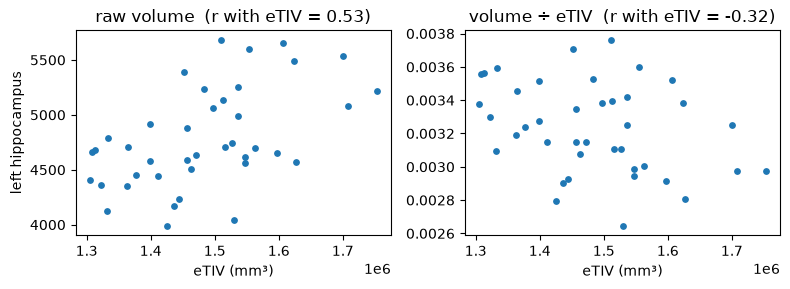

In [4]:
people = []
for i in range(40):
    write_fake_subject(tmp / f"sub-{i:02d}")
    f, q = participant_features(tmp / f"sub-{i:02d}")
    people.append({"participant_id": f"sub-{i:02d}", **f, **q})
table = pd.DataFrame(people)
scaled_cols = [c for c in table.columns if c.startswith(("area_", "vol_"))]
adjusted = normalize_by_etiv(table, scaled_cols, table["eTIV"])

col = "vol_Left-Hippocampus"
fig, axes = plt.subplots(1, 2, figsize=(8, 3))
for ax, data, title in [(axes[0], table, "raw volume"), (axes[1], adjusted, "volume ÷ eTIV")]:
    r = np.corrcoef(data["eTIV"], data[col])[0, 1]
    ax.scatter(data["eTIV"], data[col], s=15)
    ax.set_title(f"{title}  (r with eTIV = {r:.2f})")
    ax.set_xlabel("eTIV (mm³)")
axes[0].set_ylabel("left hippocampus")
plt.tight_layout()
plt.show()

## Run on the real FreeSurfer outputs
Run notebook 01 first: the manifest tells this cell which participants have a complete reconstruction. The printed feature count is the one reported in the paper.

In [5]:
USE_REAL_DATA = False

if USE_REAL_DATA:
    cfg = load_yaml(ROOT / "configs" / "data_config.yaml")
    features, quality = extract_structural_features(cfg)
    counts = {p: sum(c.startswith(p) for c in features.columns) for p in ("thick_", "area_", "vol_")}
    print(f"{len(features)} participants; features {counts} = {sum(counts.values())} total")
    display(quality.describe())
else:
    print("Synthetic mode: set USE_REAL_DATA = True once FreeSurfer outputs are in place.")

Synthetic mode: set USE_REAL_DATA = True once FreeSurfer outputs are in place.
